In [44]:
print("hello")

hello


In [45]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",as_frame=False)

In [46]:
X,y = mnist.data,mnist.target

In [47]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [48]:
X.shape

(70000, 784)

In [49]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

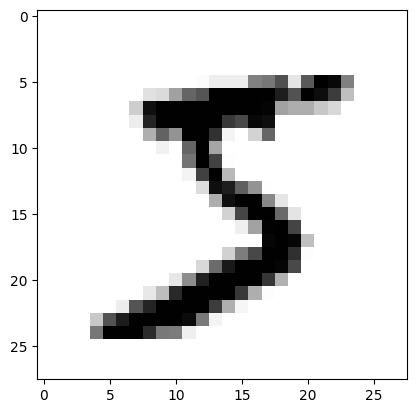

In [50]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image=image_data.reshape(28,28)
    plt.imshow(image,cmap="binary")

some_digit=X[0]
plot_digit(some_digit)
plt.show()

In [51]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [52]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train>='7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large,y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train,y_multilabel)

KNeighborsClassifier()

In [53]:
y_train_large

array([False, False, False, ..., False, False,  True])

In [54]:
y_multilabel

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [55]:
from sklearn.model_selection import cross_val_predict
y_train_knn_pred = cross_val_predict(knn_clf,X_train,y_multilabel,cv=3)

In [56]:
y_train_knn_pred

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [57]:
from sklearn.metrics import f1_score
f1_score(y_multilabel,y_train_knn_pred,average="macro")

0.9764102655606048

In [58]:
from sklearn.multioutput import ClassifierChain
from sklearn.svm import SVC
chain_clf = ClassifierChain(SVC(),cv=3,random_state=42)
chain_clf.fit(X_train[:2000],y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [59]:
chain_clf.predict([some_digit])

array([[0., 1.]])

In [60]:
np.random.seed(42)
noise = np.random.randint(0,100,(len(X_train),784))
X_train_mod=X_train+noise
noise = np.random.randint(0,100,(len(X_test),784))
X_test_mod = X_test+noise

In [61]:
y_train_mod = X_train
y_test_mod = X_test

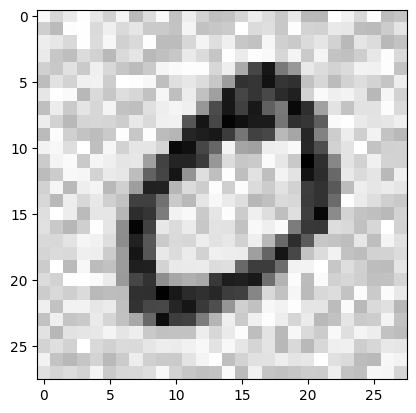

In [64]:
plot_digit(X_train_mod[1])